In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score ,  confusion_matrix , ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import joblib


In [73]:
loan_approval = pd.read_csv("C:/Users/Aryan/OneDrive/Documents/ML pract/creditwise-loan-approval/data/loan_approval_data.csv")

df = loan_approval.drop(['Applicant_ID'] , axis = 1)

# Data Understanding

In [74]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [75]:
df.shape

(1000, 19)

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    str    
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    str    
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    str    
 14  Property_Area       950 non-null    str    
 15  Education_Level     950 non-null    str    
 16  Gender            

# Handling Missing Values 

In [77]:
df.isnull().sum()

Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
# Seprating Numberical and Categorical Columns

numerical_cols = df.select_dtypes(include = ['number']).columns
catergorical_cols = df.select_dtypes(include = ['object']).columns

C:\Users\Aryan\AppData\Local\Temp\ipykernel_15508\3043344834.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catergorical_cols = df.select_dtypes(include = ['object']).columns


In [80]:
num_imputer = SimpleImputer(strategy = 'mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [81]:
cat_imputer = SimpleImputer(strategy = 'most_frequent')
df[catergorical_cols] = cat_imputer.fit_transform(df[catergorical_cols])

# EDA - Numerical Columns

In [82]:
des = df.describe().T
des['skewness'] = df.skew(numeric_only = True)
des


,count,mean,std,min,25%,50%,75%,max,skewness
Applicant_Income,1000.0,10852.571579,4933.339492,2009.0,6857.00,10852.571579,14973.25,19988.0,0.074384
Coapplicant_Income,1000.0,5082.455789,2868.563488,1.0,2701.25,5082.455789,7452.75,9996.0,-0.052473
Age,1000.0,39.971579,10.857445,21.0,31.00,39.971579,49.00,59.0,-0.021224
Dependents,1000.0,1.474737,1.077058,0.0,1.00,1.237368,2.00,3.0,0.068112
Credit_Score,1000.0,676.033684,69.537662,550.0,618.00,676.033684,735.00,799.0,-0.060414
Existing_Loans,1000.0,1.950526,1.370603,0.0,1.00,2.000000,3.00,4.0,0.083230
DTI_Ratio,1000.0,0.347263,0.140683,0.1,0.23,0.347263,0.47,0.6,0.057100
Savings,1000.0,9940.452632,5712.189236,65.0,4964.00,9940.452632,14784.75,19996.0,0.010815
Collateral_Value,1000.0,24802.792632,13982.086562,36.0,13166.00,24802.792632,36396.00,49954.0,0.065935
Loan_Amount,1000.0,20522.825263,11212.555805,1015.0,10478.25,20522.825263,29683.25,39995.0,-0.026282


In this observation , I can see that in Coapplicant_Income the minimum income is 1 , so it should be properly check and handeled  

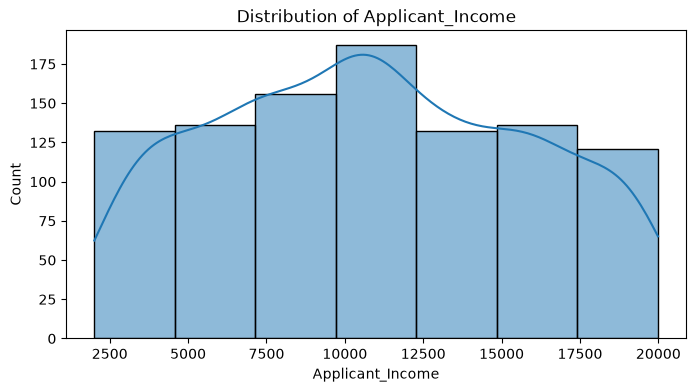

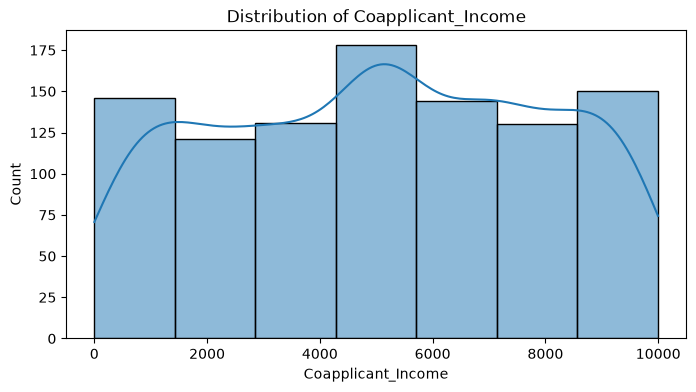

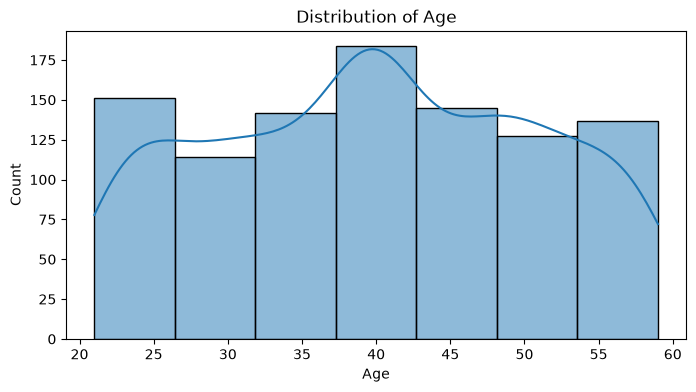

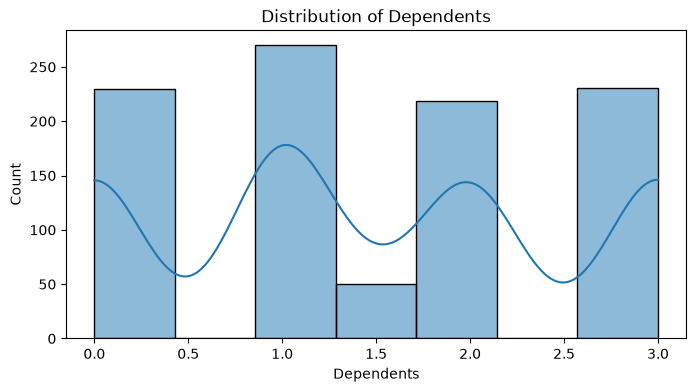

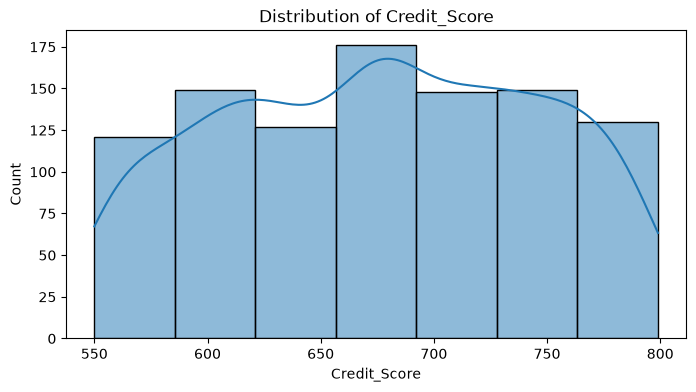

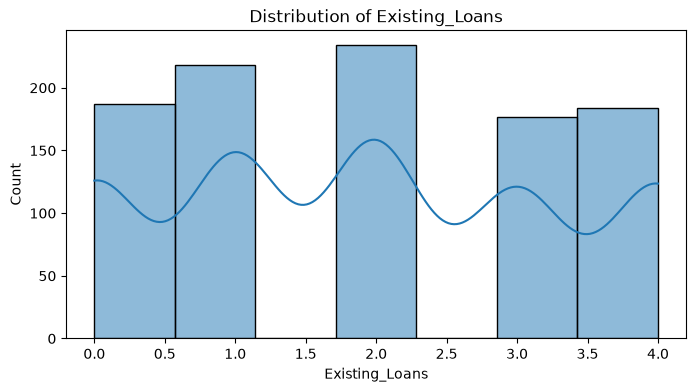

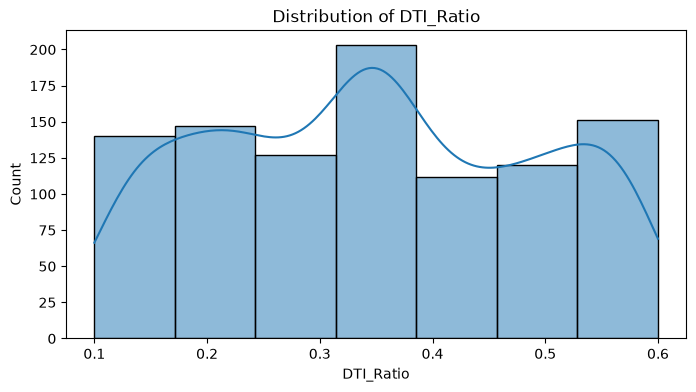

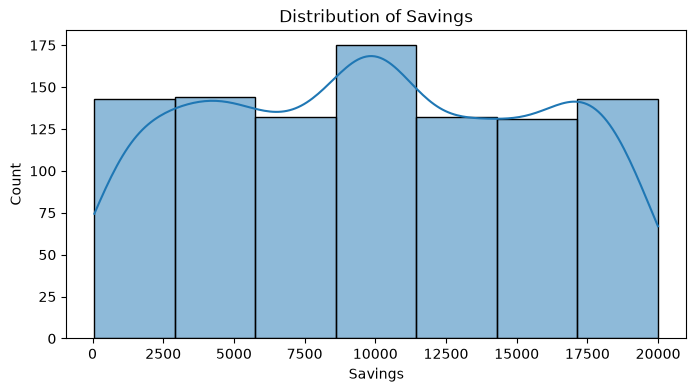

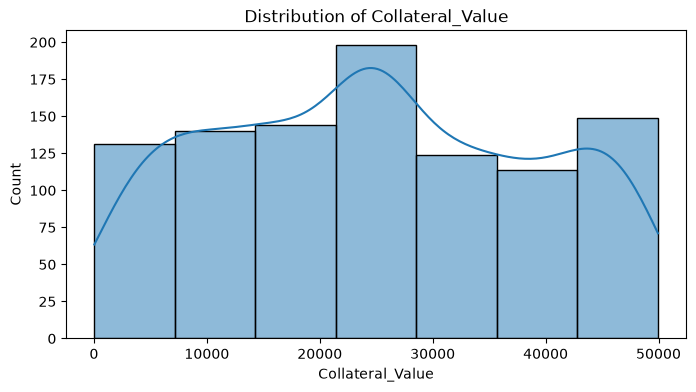

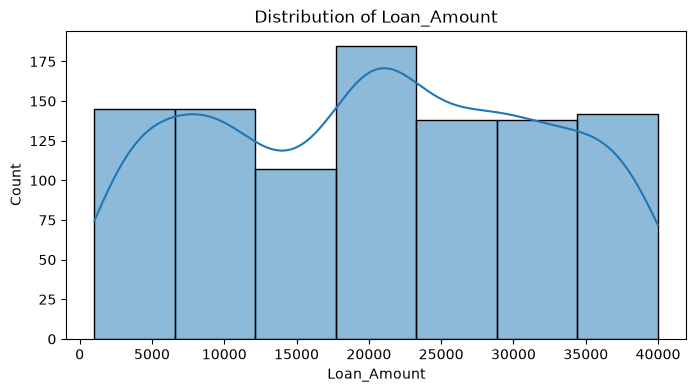

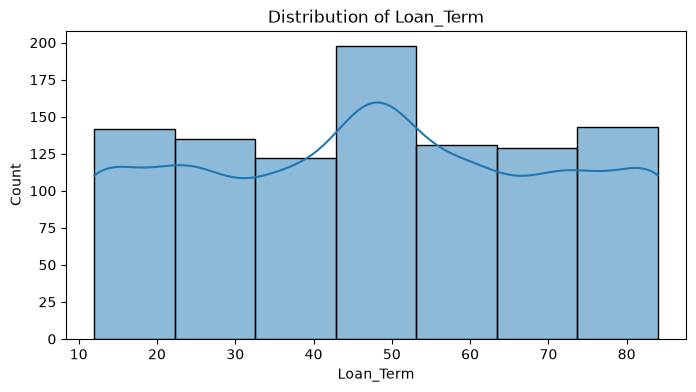

In [83]:
for cols in numerical_cols:
    plt.figure(figsize = (8,4))
    sns.histplot(data = df , x = cols , kde= True ,bins =7),
    plt.title(f"Distribution of {cols}"),
    plt.show()


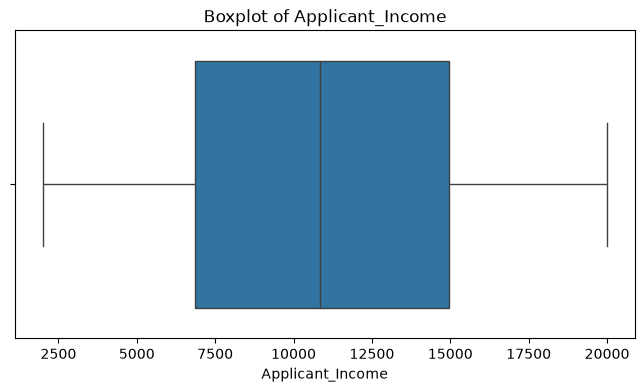

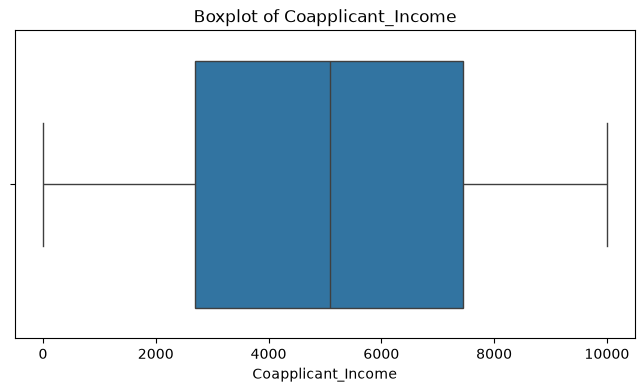

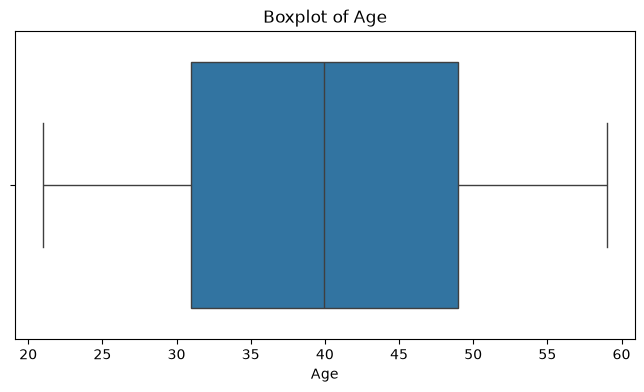

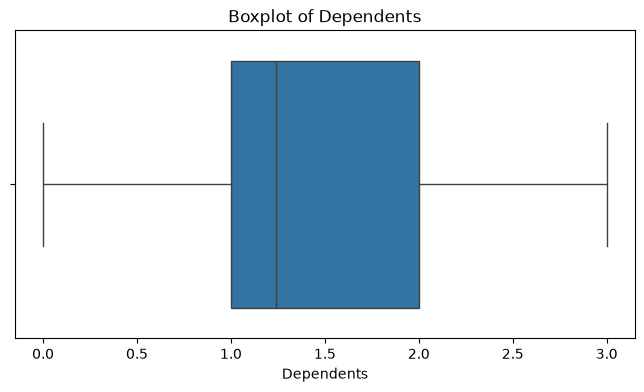

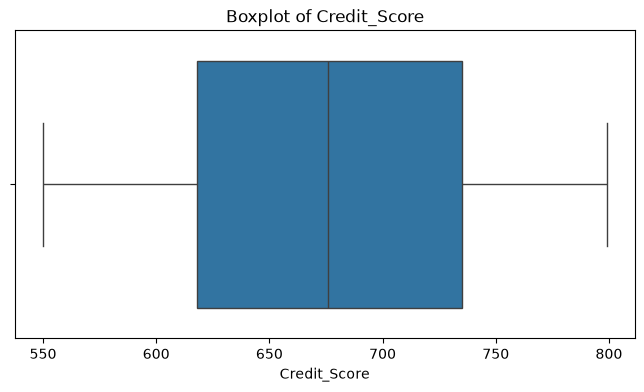

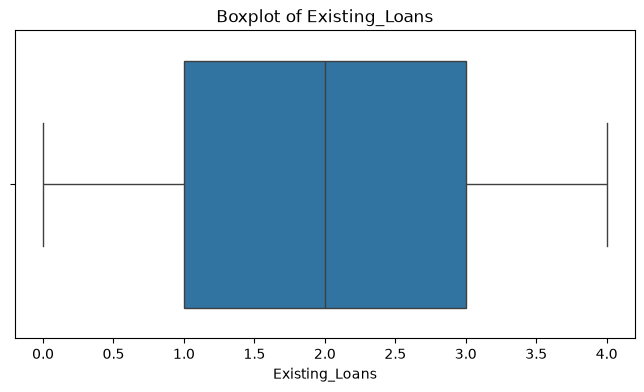

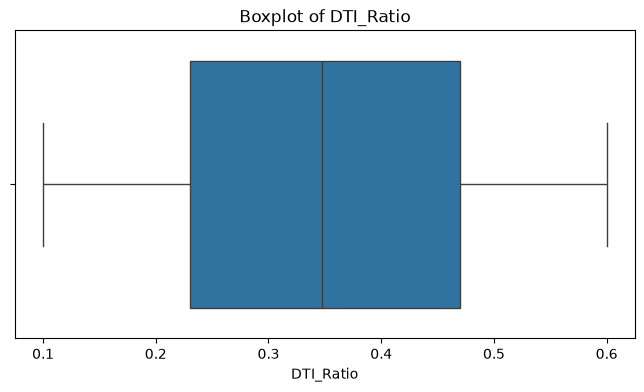

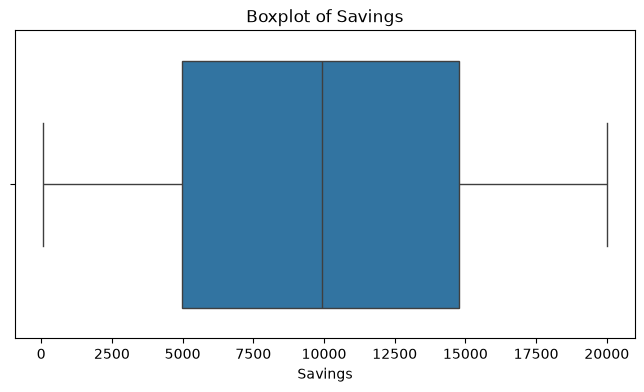

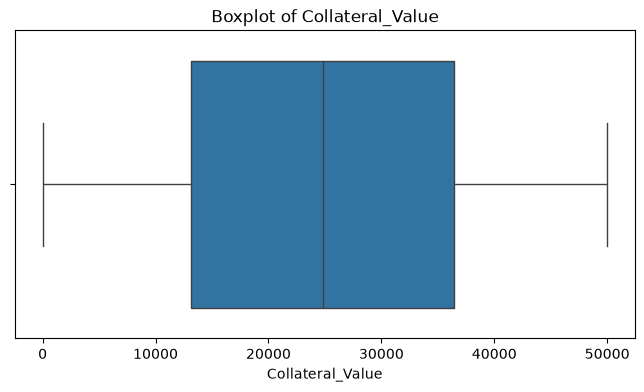

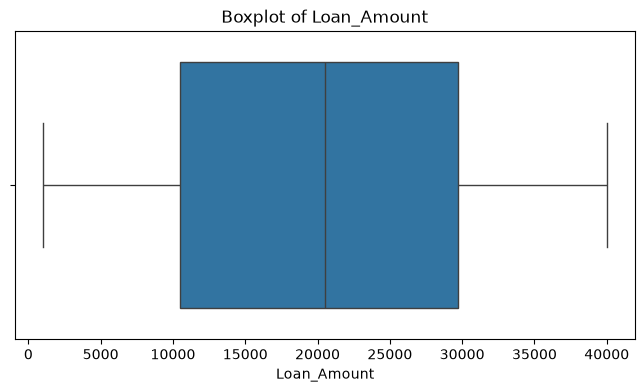

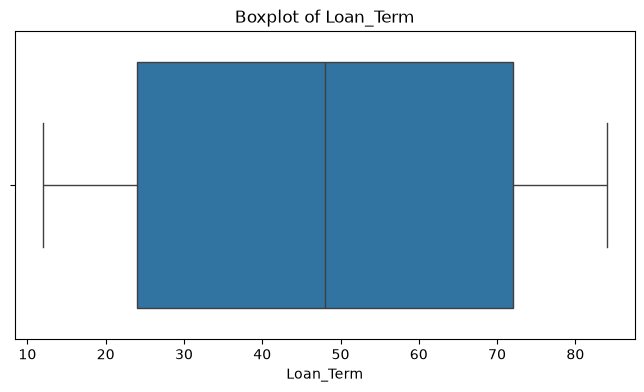

In [84]:
for cols in numerical_cols:
    plt.figure(figsize = (8,4))
    sns.boxplot(x=df[cols]),
    plt.title(f"Boxplot of {cols}"),
    plt.show()


# EDA - Catergorical Columns

In [85]:
des_cat = df.describe(include = 'object').T
des_cat

C:\Users\Aryan\AppData\Local\Temp\ipykernel_15508\4234072645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  des_cat = df.describe(include = 'object').T


,count,unique,top,freq
Employment_Status,1000,4,Salaried,515
Marital_Status,1000,2,Married,643
Loan_Purpose,1000,5,Business,252
Property_Area,1000,3,Urban,517
Education_Level,1000,2,Graduate,722
Gender,1000,2,Male,621
Employer_Category,1000,5,Private,422
Loan_Approved,1000,2,No,702


## Loan Approved

In [86]:
df['Loan_Approved'].value_counts(normalize = True) * 100

Loan_Approved
No     70.2
Yes    29.8
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Loan_Approved Value Counts')

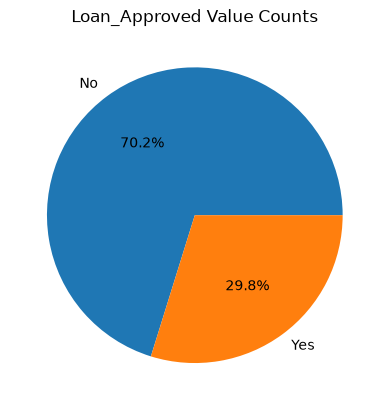

In [87]:
df['Loan_Approved'].value_counts(normalize = True).plot(kind = 'pie' , autopct = "%1.1f%%" , labels = ['No' , 'Yes'])
plt.title("Loan_Approved Value Counts")

## Gender  

In [88]:
df['Gender'].value_counts()

Gender
Male      621
Female    379
Name: count, dtype: int64

In [89]:
df.groupby('Gender')['Loan_Approved'].value_counts()

Gender  Loan_Approved
Female  No               254
        Yes              125
Male    No               448
        Yes              173
Name: count, dtype: int64

Text(0.5, 1.0, 'Gender Value Counts')

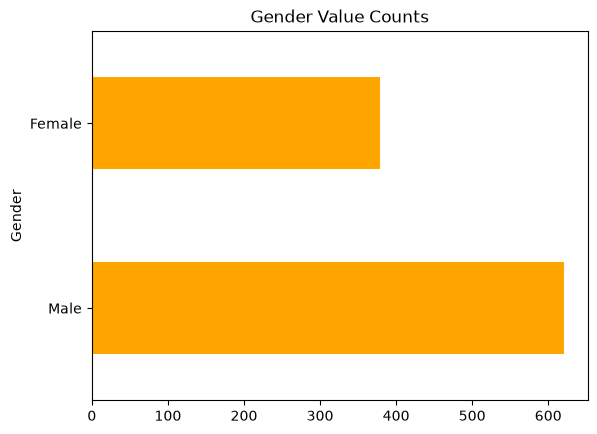

In [90]:
df['Gender'].value_counts().plot(kind = 'barh' , color = 'orange')
plt.title('Gender Value Counts')

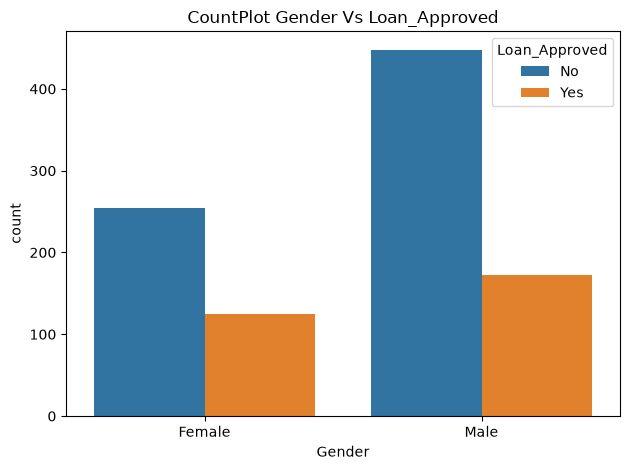

In [91]:
sns.countplot(
    data = df,
    x = "Gender",
    hue = "Loan_Approved"
)
plt.title("CountPlot Gender Vs Loan_Approved")
plt.tight_layout()
plt.show()

## Employment_Status

<Axes: xlabel='Employment_Status'>

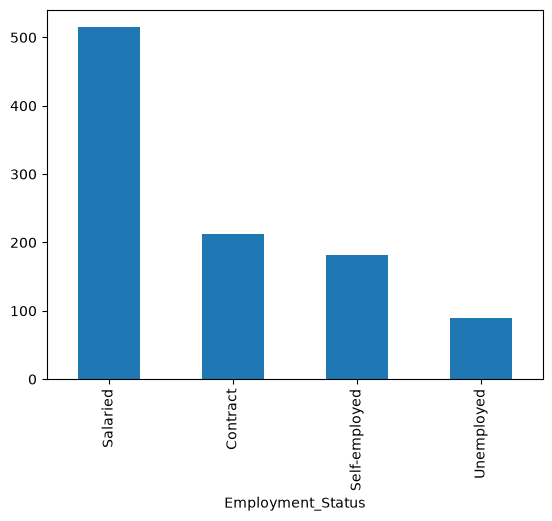

In [92]:
df['Employment_Status'].value_counts().plot(kind = "bar")

In [93]:
df.groupby('Employment_Status')['Loan_Approved'].value_counts()

Employment_Status  Loan_Approved
Contract           No               134
                   Yes               79
Salaried           No               371
                   Yes              144
Self-employed      No               128
                   Yes               54
Unemployed         No                69
                   Yes               21
Name: count, dtype: int64

<Axes: xlabel='Employment_Status', ylabel='count'>

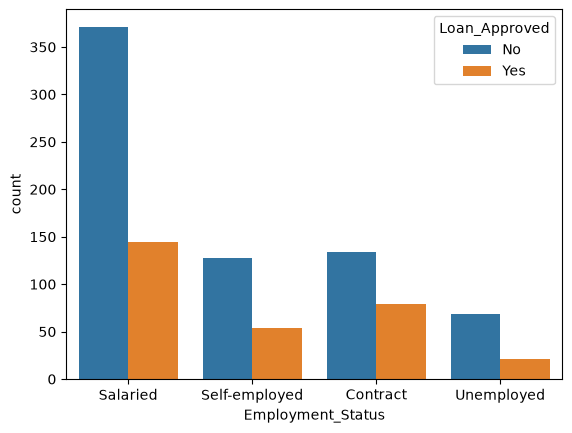

In [94]:
sns.countplot(
    data = df,
    x = "Employment_Status",
    hue = "Loan_Approved"
)

In [95]:
df['Marital_Status'].value_counts()

Marital_Status
Married    643
Single     357
Name: count, dtype: int64

In [96]:
df['Marital_Status'].value_counts()

Marital_Status
Married    643
Single     357
Name: count, dtype: int64

In [97]:
df.groupby('Marital_Status')['Loan_Approved'].value_counts()

Marital_Status  Loan_Approved
Married         No               458
                Yes              185
Single          No               244
                Yes              113
Name: count, dtype: int64

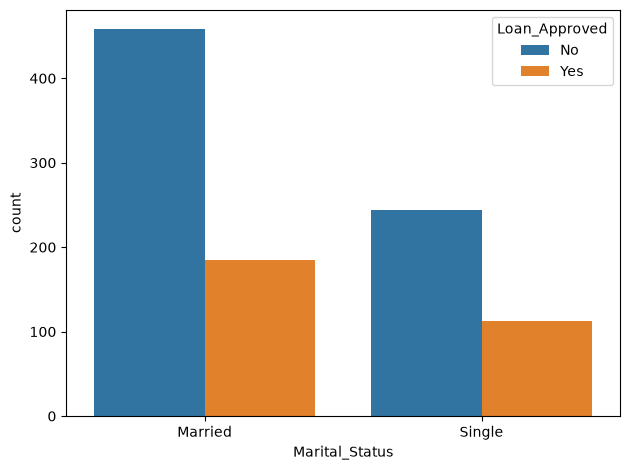

In [98]:
sns.countplot(
    data = df,
    x = 'Marital_Status',
    hue = 'Loan_Approved'
)

plt.tight_layout()
plt.show()

<Axes: xlabel='Employer_Category', ylabel='count'>

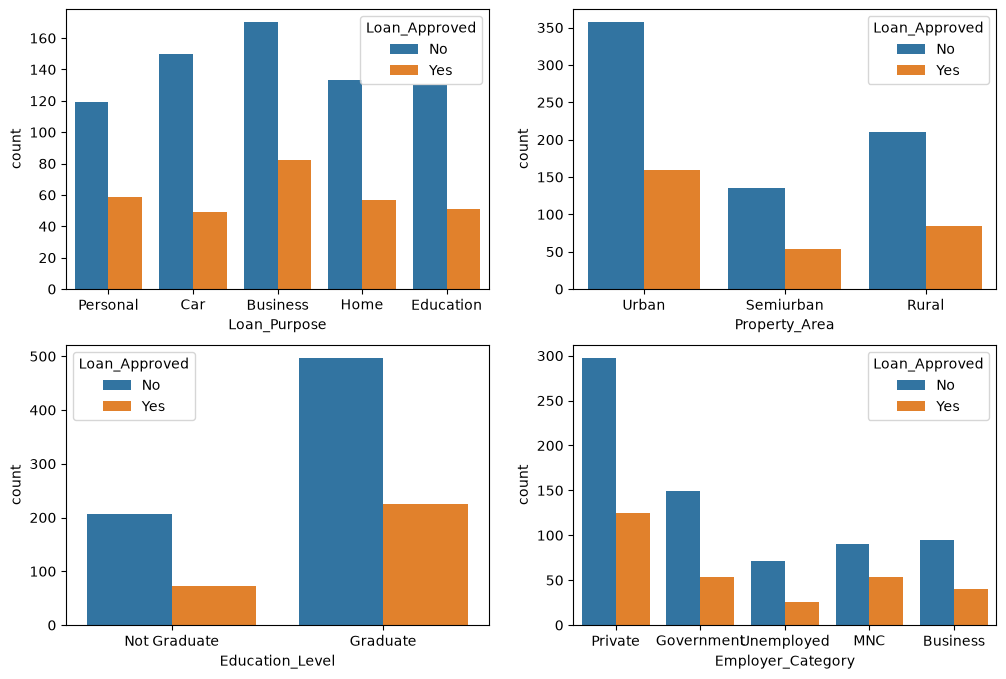

In [99]:
fig , ax = plt.subplots(2,2 , figsize = (12,8))

sns.countplot(data = df , x = "Loan_Purpose" , hue = "Loan_Approved", ax = ax[0][0])
sns.countplot(data = df , x = "Property_Area" , hue = "Loan_Approved" , ax = ax[0][1])
sns.countplot(data = df , x = "Education_Level" , hue = "Loan_Approved" , ax= ax[1][0])
sns.countplot(data = df , x = "Employer_Category" , hue = "Loan_Approved" , ax = ax[1][1])

# Feature Engeneering

In [100]:
df.head()
df2 = df.copy()
df2.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [101]:
ohe_cols  = df2[['Employment_Status','Marital_Status' , 'Loan_Purpose' ,'Property_Area', 'Gender', 'Employer_Category' ]].columns

In [102]:
df2 = pd.get_dummies(df2 , columns = ohe_cols , drop_first=True , dtype = 'int64')

In [103]:
lbe_cols = df2.select_dtypes(include = 'object').columns

C:\Users\Aryan\AppData\Local\Temp\ipykernel_15508\404870982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  lbe_cols = df2.select_dtypes(include = 'object').columns


In [104]:
le = LabelEncoder()

for lbe in lbe_cols:
    df2[lbe] = le.fit_transform(df2[lbe])


df2.head()

In [105]:
df2[df2['Coapplicant_Income'] < 100]['Coapplicant_Income'].value_counts()

Coapplicant_Income
74.0    1
60.0    1
38.0    1
89.0    1
21.0    1
1.0     1
13.0    1
11.0    1
9.0     1
72.0    1
Name: count, dtype: int64

There are 10 observation where Coapplicant_Income is less than 100 . Since there is no mention in the dataset, we will keep it.

In [106]:
corr_matx = df2.corr()

In [107]:
corr_matx['Loan_Approved'].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

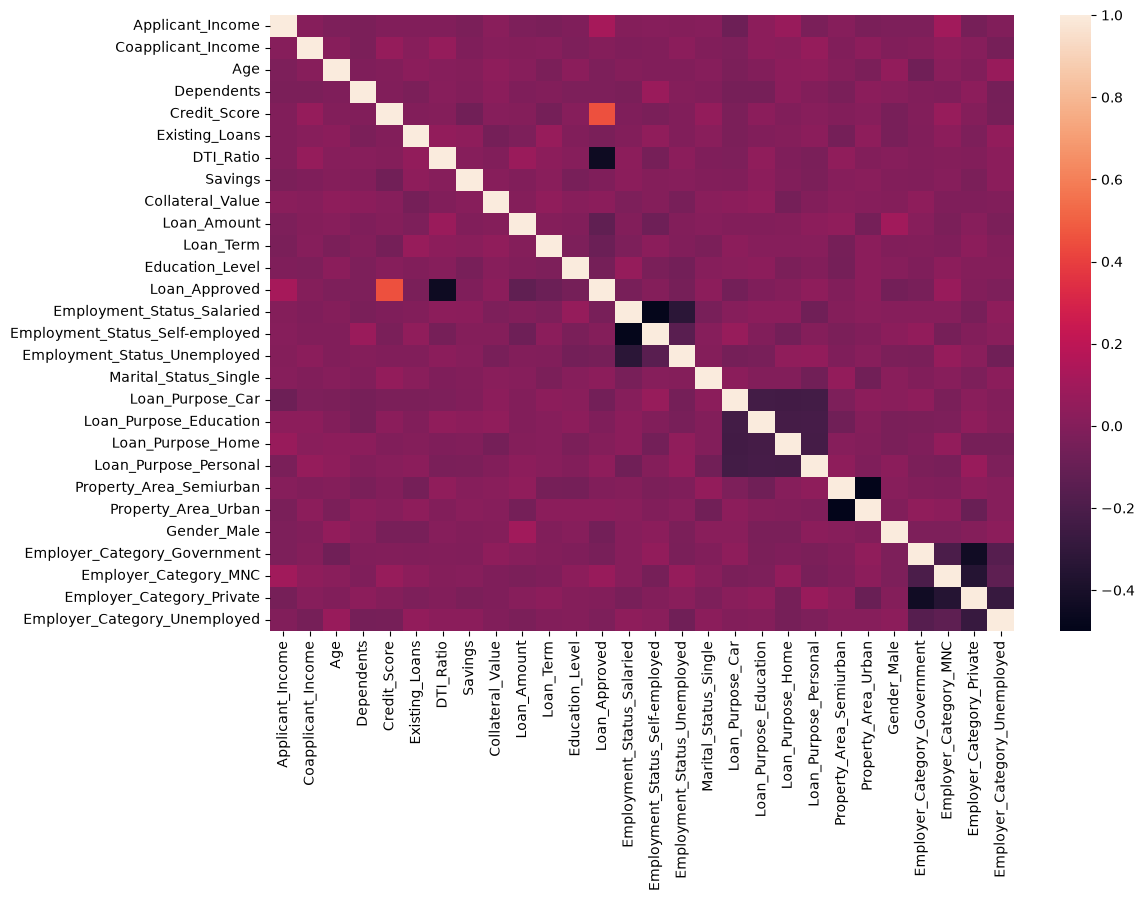

In [108]:
plt.figure(figsize = (12,8))

sns.heatmap(
    corr_matx,
)

In [109]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

# Model Training

In [110]:
X = df2.drop('Loan_Approved' , axis = 1)
y = df2['Loan_Approved']

X_train , X_test , y_train , y_test = train_test_split(
    X , y , random_state = 42 , train_size = 0.3 , stratify=y
)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

## Logistic Regression

In [111]:
pipe = Pipeline([('scalar' , StandardScaler()) , ('logistic' , LogisticRegression(max_iter=1000 , solver= 'liblinear'))])

param_grid = {
    'logistic__C' : [0.1 , 0.2 , 0.01 , 2 , 3],
    'logistic__penalty' : ['l1' , 'l2'],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv = 5,
    scoring = 'f1'
)

grid.fit(X_train , y_train)
print(grid.best_params_)


c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

{'logistic__C': 0.2, 'logistic__penalty': 'l1'}


c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Aryan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

In [112]:
log_best_model = grid.best_estimator_
y_pred = grid.predict(X_test)

log_acc = accuracy_score(y_test , y_pred)
log_precision = precision_score(y_test , y_pred)
log_recall = recall_score(y_test , y_pred)
log_f1 = f1_score(y_test , y_pred)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8385714285714285
Precision: 0.7307692307692307
Recall: 0.7272727272727273
F1: 0.7290167865707434


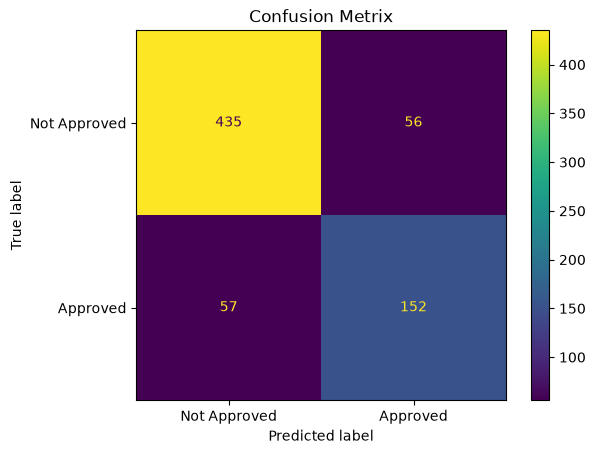

In [113]:
ConfusionMatrixDisplay.from_estimator(
    log_best_model,
    X_test,
    y_test,
    display_labels = ['Not Approved' , 'Approved']
)

plt.title("Confusion Metrix")
plt.show()

# KNN

In [114]:
pipe = Pipeline([
    ('scalar' , StandardScaler()),
    ('knn' , KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors' : [3,5,7,9,11,13],
    'knn__weights' : ['uniform' , 'distance'],
    'knn__algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv = 5,
    scoring = 'f1'
)

grid.fit(X_train , y_train)
print(grid.best_params_)

{'knn__algorithm': 'auto', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}


In [115]:
knn_model = grid.best_estimator_
y_pred = grid.predict(X_test)


knn_acc = accuracy_score(y_test , y_pred)
knn_precision = precision_score(y_test , y_pred)
knn_recall = recall_score(y_test , y_pred)
knn_f1 = f1_score(y_test , y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.7042857142857143
Precision: 0.5064935064935064
Recall: 0.37320574162679426
F1: 0.4297520661157025


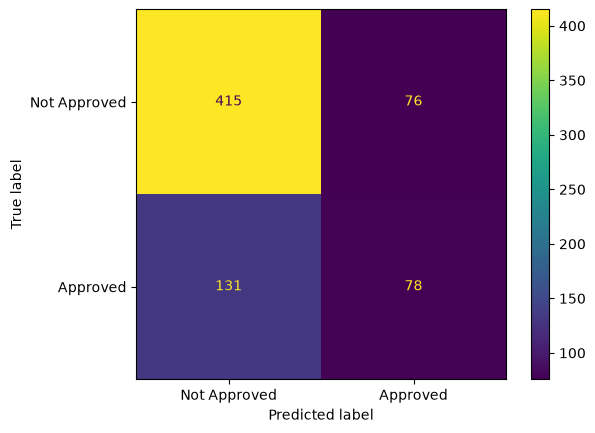

In [116]:
ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    display_labels = ["Not Approved" , "Approved"]
)

plt.show()

# SVC

In [117]:
pipe = Pipeline([
    ('scalar' , StandardScaler()),
    ('svc' , SVC())
])

param_grid = {
    'svc__C' : [0.1,0.01,0.2,0.3,0.4,0.5,0.6],
    'svc__kernel' : ['rbf' , 'linear' , 'poly' , 'sigmoid'],
    'svc__gamma' : ['scale' , 'auto']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv = 5,
    scoring = 'f1'
)

grid.fit(X_train , y_train)
print(grid.best_params_)

{'svc__C': 0.6, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}


In [118]:
svc_model = grid.best_estimator_
y_pred = grid.predict(X_test)

svc_acc = accuracy_score(y_test , y_pred)
svc_precision = precision_score(y_test , y_pred)
svc_recall = recall_score(y_test , y_pred)
svc_f1 = f1_score(y_test , y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.82
Precision: 0.6812227074235808
Recall: 0.7464114832535885
F1: 0.7123287671232876


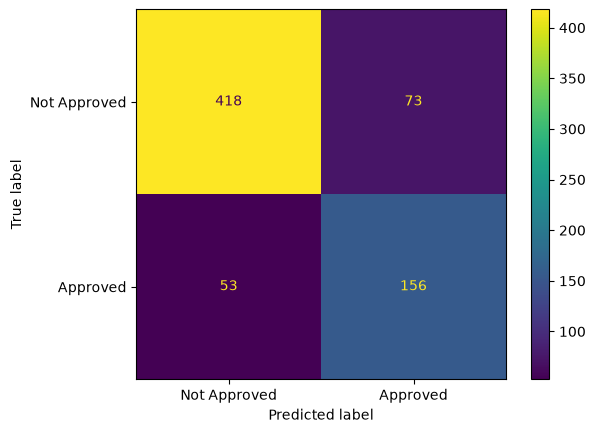

In [119]:
ConfusionMatrixDisplay.from_estimator(
    svc_model,
    X_test , 
    y_test,
    display_labels=["Not Approved" , "Approved"]
)

# RandomForestClassifier

In [120]:
estimator = RandomForestClassifier()

params = {
    'n_estimators' : [100],
    'min_samples_split' : [3,4,5,6],
    'max_depth' : [6,7,9,10],
    'max_features' : ['sqrt' , 'log2' , None],

}

grid = GridSearchCV(
    estimator,
    params,
    cv = 5,
    scoring = 'f1'
    
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 6, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 100}


In [121]:
randomforest_classifier = grid.best_estimator_
y_pred = grid.predict(X_test)

rbc_acc = accuracy_score(y_test , y_pred)
rbc_precision = precision_score(y_test , y_pred)
rbc_recall = recall_score(y_test , y_pred)
rbc_f1 = f1_score(y_test , y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9285714285714286
Precision: 0.8382978723404255
Recall: 0.9425837320574163
F1: 0.8873873873873874


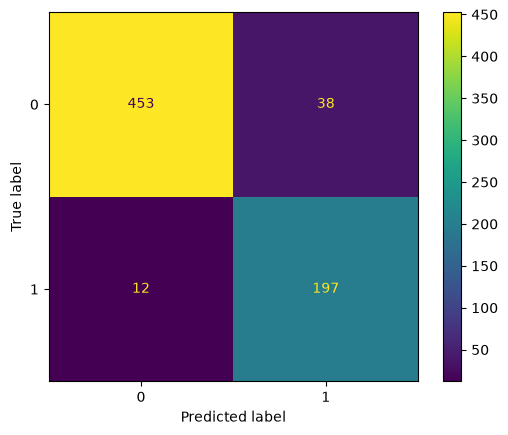

In [122]:
ConfusionMatrixDisplay.from_estimator(
    randomforest_classifier,
    X_test,
    y_test
)

<Axes: xlabel='Importance', ylabel='Feature'>

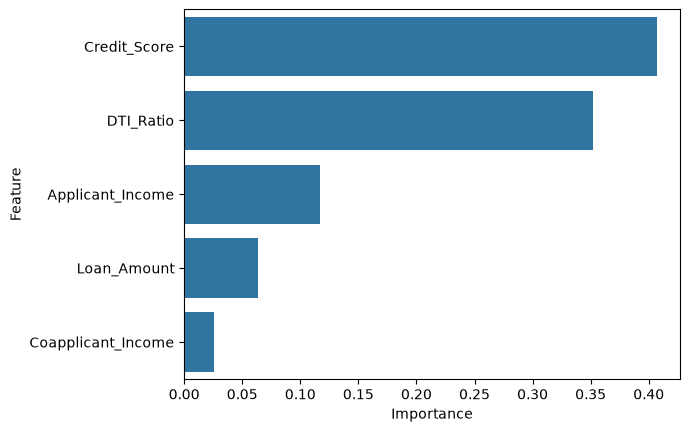

In [123]:
feature_importance = pd.DataFrame({
    "Feature" : X_test.columns,
    "Importance" : randomforest_classifier.feature_importances_
})

feature_importance.sort_values(
    by = "Importance",
    ascending = False
)

sns.barplot(
    data = feature_importance.sort_values(by = 'Importance' , ascending = False).head(),
    x = "Importance",
    y = "Feature"
)


# AdaBoost Classifier

In [124]:
adaboost = AdaBoostClassifier(n_estimators = 100,random_state=42)

adaboost.fit(X_train , y_train)
y_pred = adaboost.predict(X_test)

ada_acc = accuracy_score(y_test , y_pred)
ada_precision = precision_score(y_test , y_pred)
ada_recall = recall_score(y_test , y_pred)
ada_f1 = f1_score(y_test , y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9214285714285714
Precision: 0.8130081300813008
Recall: 0.9569377990430622
F1: 0.8791208791208791


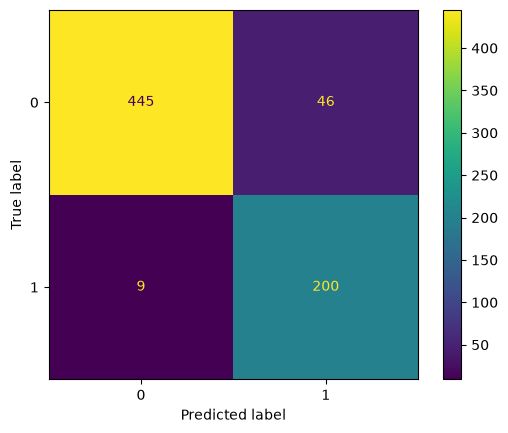

In [125]:
ConfusionMatrixDisplay.from_estimator(
    adaboost,
    X_test,
    y_test
)

Adaptive Boost and Random Forest have almost similar evaluations , but sincr random forest have a little better f1_Score , we will go with that.

In [126]:
metrics = pd.DataFrame({
    "Models": ['Logistic_Regression' , 'KNN' , 'SVC' , 'RandomForestClassifier' , 'AdaBoost Classifier'],
    "Accuracy" : [log_acc , knn_acc , svc_acc , rbc_acc , ada_acc],
    "Precision" : [log_precision , knn_precision , svc_precision, rbc_precision , ada_precision],
    "Recall" : [log_recall , knn_recall ,svc_recall, rbc_recall , ada_recall],
    "F1_Score" : [log_f1 , knn_f1 ,svc_f1, rbc_f1 , ada_f1]
    

})

metrics

,Models,Accuracy,Precision,Recall,F1_Score
0,Logistic_Regression,0.838571,0.730769,0.727273,0.729017
1,KNN,0.704286,0.506494,0.373206,0.429752
2,SVC,0.820000,0.681223,0.746411,0.712329
3,RandomForestClassifier,0.928571,0.838298,0.942584,0.887387
4,AdaBoost Classifier,0.921429,0.813008,0.956938,0.879121


# Final Model

In [127]:
best_model = RandomForestClassifier(n_estimators=100 , max_depth=7 , min_samples_split=3 , max_features=None , criterion='entropy')
best_model.fit(X_train , y_train)
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.94
Precision: 0.8464730290456431
Recall: 0.9760765550239234
F1: 0.9066666666666666


# Storing the best model

In [128]:
joblib.dump(best_model , "../model/creditwise-loan-model.pkl")

['../model/creditwise-loan-model.pkl']

In [129]:
load_model = joblib.load("../model/creditwise-loan-model.pkl")
predictions = load_model.predict(X_test)
print(predictions[:5])


[0 0 0 1 0]


In [130]:
feature_columns = X_test.columns.tolist()
joblib.dump(feature_columns , "../model/feature-columns.pkl")

['../model/feature-columns.pkl']

In [134]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [136]:
df['Marital_Status'].unique()

<StringArray>
['Married', 'Single']
Length: 2, dtype: str